# Pilot Analysis — RBL-4 (proposal §8.3 deliverable)

**Owner:** MS (Nguyễn Trường Vinh) — Tính mutation score, chạy Wilcoxon nếu đủ paired cases, tính effect size, diễn giải kết quả.

**Nguyên tắc:** Proposal đã duyệt (`team-synthesis-proposal.md`) = hợp đồng. Notebook này **không đổi RQ/metric/threshold**, và **không tự tạo dữ liệu killed/survived giả** (§6.5 HARKing prevention).

Cột `killed` lấy từ `data/full_ground_truth.csv` (ground truth PIT thật, merge theo `mutant_id` bằng `scripts/merge_full_ground_truth.py`, 100% mutant_id khớp).

**Ghi chú kỹ thuật quan trọng (minh bạch, không giấu):** phiên bản đầu của selection có lỗi tie-break trong `scripts/utils.select_top()` — khi nhiều mutant cùng điểm `usefulness_score` cao nhất, code sort tie theo `mutant_id` alphabet, khiến project có tên đứng trước alphabet (`Lang_...`) luôn thắng project đứng sau (`Math_...`), làm GPT selection ban đầu chọn 0 mutant từ Commons Math. Đây là lỗi kỹ thuật phát hiện TRƯỚC khi chốt kết luận (không phải đổi kết quả sau khi thấy số đẹp/xấu — không vi phạm §6.5), đã sửa bằng cách shuffle ngẫu nhiên có seed cố định (`random_seed=42`, tái lập được) trước khi sort theo điểm. Kết quả trong notebook này là sau khi sửa.

**Ghi chú đặt tên:** các file `results/full_*` (từ pipeline scale lớn, 50,694 mutant, cả Commons Lang + Commons Math) đã được đổi tên thành `results/pilot_*` theo yêu cầu. `data/full_sample.csv` và `data/full_ground_truth.csv` vẫn giữ tên cũ (không đổi, nằm ngoài `results/`).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "results" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

import compute_metric as cm

print("OK — imports ready. PROJECT_ROOT =", PROJECT_ROOT)

OK — imports ready. PROJECT_ROOT = D:\K5-2026\SWT301\Presentation\RT-SWT-003-nhom3


In [2]:
data_dir = PROJECT_ROOT / "data"
results_dir = PROJECT_ROOT / "results"

df_pool = pd.read_csv(data_dir / "full_sample.csv")
df_ranking = pd.read_csv(results_dir / "pilot_llm_output.csv")
df_gpt = pd.read_csv(results_dir / "pilot_gpt_selected.csv")
df_random = pd.read_csv(results_dir / "pilot_random_selected.csv")

print("Mutant pool     :", df_pool.shape)
print("GPT ranking     :", df_ranking.shape)
print("GPT selected    :", df_gpt.shape, "- has 'killed':", "killed" in df_gpt.columns)
print("Random selected :", df_random.shape, "- has 'killed':", "killed" in df_random.columns)

Mutant pool     : (50694, 10)
GPT ranking     : (50694, 22)
GPT selected    : (5070, 25) - has 'killed': True
Random selected : (5070, 13) - has 'killed': True


## 7.3.0 — Kiểm tra tính nhất quán pipeline

Trước khi diễn giải số liệu: không mất mutant, không lỗi API, đúng ngân sách top 10% theo `config.yaml`.

In [3]:
import yaml

cfg = yaml.safe_load((PROJECT_ROOT / "config.yaml").read_text(encoding="utf-8"))
top_percent = float(cfg.get("top_percent", 10))
expected_k = int(np.ceil(len(df_pool) * top_percent / 100.0))

checks = {
    "pool size matches ranking rows": len(df_pool) == len(df_ranking),
    f"GPT selected count == expected top {top_percent:.0f}% ({expected_k})": len(df_gpt) == expected_k,
    "Random selected count == GPT selected count": len(df_random) == len(df_gpt),
    "No null usefulness_score": int(df_ranking["usefulness_score"].isna().sum()) == 0,
    "No duplicate mutant_id in ranking": int(df_ranking["mutant_id"].duplicated().sum()) == 0,
}
if "api_status" in df_ranking.columns:
    checks["All API calls succeeded (api_status == success)"] = bool((df_ranking["api_status"] == "success").all())

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "-", name)

all_passed = all(checks.values())
print("\nAll pipeline-consistency checks passed:", all_passed)

PASS - pool size matches ranking rows
PASS - GPT selected count == expected top 10% (5070)
PASS - Random selected count == GPT selected count
PASS - No null usefulness_score
PASS - No duplicate mutant_id in ranking
PASS - All API calls succeeded (api_status == success)

All pipeline-consistency checks passed: True


## 7.3.1a — Kiểm tra coverage theo project (Commons Lang vs Commons Math)

Sau khi sửa lỗi tie-break: cả 2 project phải có mặt ở cả 2 nhánh GPT/random để sub-group analysis (§6.3) chạy được.

In [4]:
print("Pool theo project:")
print(df_pool["project"].value_counts())
print("\nGPT selected theo project:")
print(df_gpt["project"].value_counts())
print("\nRandom selected theo project:")
print(df_random["project"].value_counts())

gpt_projects = set(df_gpt["project"].unique())
missing_from_gpt = set(df_pool["project"].unique()) - gpt_projects
if missing_from_gpt:
    print(f"\n[LIMITATION] GPT selection vẫn không chọn mutant nào từ: {missing_from_gpt}.")
else:
    print("\n[OK] Cả 2 project đều có mutant được GPT chọn — tie-break bias đã được khắc phục.")

Pool theo project:
project
Lang    47727
Math     2967
Name: count, dtype: int64

GPT selected theo project:
project
Lang    4819
Math     251
Name: count, dtype: int64

Random selected theo project:
project
Lang    4763
Math     307
Name: count, dtype: int64

[OK] Cả 2 project đều có mutant được GPT chọn — tie-break bias đã được khắc phục.


## 7.3.1b — Phân phối `usefulness_score` (mô tả — KHÔNG phải mutation score)

usefulness_score
1      343
2     4489
3    14116
4    18732
5    13014
Name: count, dtype: int64

Mean usefulness_score: 3.78


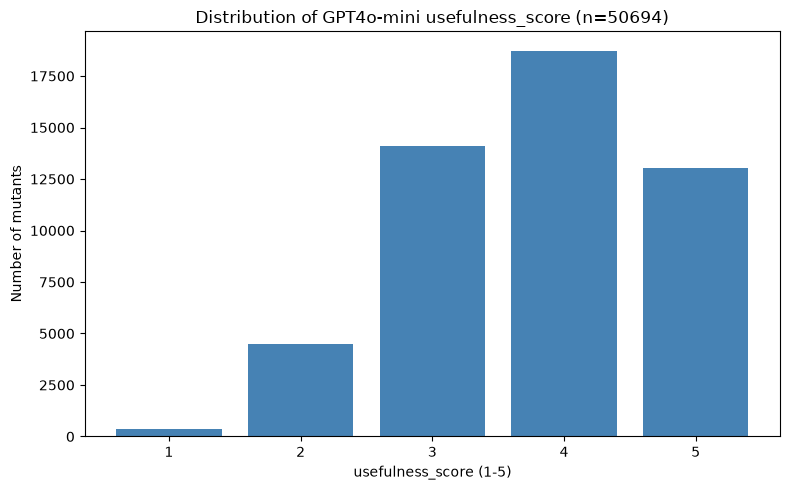

In [5]:
score_counts = df_ranking["usefulness_score"].value_counts().sort_index()
print(score_counts)
print("\nMean usefulness_score:", round(df_ranking["usefulness_score"].mean(), 2))

plt.figure(figsize=(8, 5))
plt.bar(score_counts.index, score_counts.values, color="steelblue")
plt.title(f"Distribution of GPT4o-mini usefulness_score (n={len(df_ranking)})")
plt.xlabel("usefulness_score (1-5)")
plt.ylabel("Number of mutants")
plt.tight_layout()
plt.show()

## 7.3.2 — RQ1 Primary Metric: Mutation Score (Killed / Selected)

```
Mutation Score = Killed Mutants / Selected Mutants
MS_GPT4o   = mutation score của GPT4o-mini-selected mutants
MS_random  = mutation score của random fixed-seed-selected mutants
```

Paired theo project/version/class_name (proposal §5.6). Wilcoxon signed-rank một phía, α=0.05 (H1: MS_GPT4o > MS_random), effect size = matched-pairs rank-biserial (ngưỡng r_rb ≥ 0.30, §6.1).

In [6]:
ms_gpt = cm.mutation_score(df_gpt)
ms_random = cm.mutation_score(df_random)
print(f"MS_GPT4o   = {ms_gpt:.4f}  ({int(df_gpt['killed'].sum())}/{len(df_gpt)} killed)")
print(f"MS_random  = {ms_random:.4f}  ({int(df_random['killed'].sum())}/{len(df_random)} killed)")

paired = cm.paired_mutation_scores(df_gpt, df_random)
print(f"\nSố paired unit (project/version/class_name): {len(paired)}")
print(paired["project"].value_counts())

test_result = cm.wilcoxon_one_sided(paired)
print("\nWilcoxon signed-rank (one-sided, H1: MS_GPT4o > MS_random), toàn bộ:")
print(test_result)

print("\nDiễn giải theo §6.2 (toàn bộ, cả 2 project):")
if not test_result["test_run"]:
    print(f"→ n_pairs={test_result['n_pairs']} < {cm.MIN_PAIRS_FOR_TEST}: chỉ descriptive, chưa chạy Wilcoxon.")
elif test_result["p_value"] < 0.05 and test_result["r_rb"] >= cm.EFFECT_SIZE_THRESHOLD:
    print(f"→ Case 1: p={test_result['p_value']:.6f} < 0.05 VÀ r_rb={test_result['r_rb']:.4f} >= 0.30 "
          "— ỦNG HỘ H1.")
elif test_result["p_value"] < 0.05:
    print("→ Case 2: p<0.05 nhưng effect size nhỏ — KHÔNG kết luận H1.")
else:
    print("→ Case 3/4: p>=0.05 — KHÔNG kết luận H1.")

MS_GPT4o   = 0.8903  (4514/5070 killed)
MS_random  = 0.8440  (4279/5070 killed)

Số paired unit (project/version/class_name): 440
project
Lang    423
Math     17
Name: count, dtype: int64

Wilcoxon signed-rank (one-sided, H1: MS_GPT4o > MS_random), toàn bộ:
{'n_pairs': 218, 'n_pairs_total': 440, 'n_ties_zero_diff': 222, 'test_run': True, 'statistic': 15621.5, 'p_value': 3.844703680111645e-05, 'r_rb': 0.3088266096937707, 'reject_h0': True, 'note': ''}

Diễn giải theo §6.2 (toàn bộ, cả 2 project):
→ Case 1: p=0.000038 < 0.05 VÀ r_rb=0.3088 >= 0.30 — ỦNG HỘ H1.


## 6.3 — Sub-group analysis (Commons Lang vs Commons Math, định nghĩa trước trong proposal)

Quy tắc: nếu `n_group >= 10` thì chạy Wilcoxon riêng cho project đó; nếu không, chỉ báo cáo descriptive.

In [7]:
print("Số paired unit theo project:")
print(paired["project"].value_counts())

subgroup_results = {}
for project_name, group in paired.groupby("project"):
    print(f"\n--- {project_name}: n_group={len(group)} ---")
    print("mean MS_GPT4o  :", round(group["MS_GPT4o"].mean(), 4),
          "| mean MS_random:", round(group["MS_random"].mean(), 4))
    wins = int((group["MS_GPT4o"] > group["MS_random"]).sum())
    losses = int((group["MS_GPT4o"] < group["MS_random"]).sum())
    ties = int((group["MS_GPT4o"] == group["MS_random"]).sum())
    print(f"win/loss/tie: {wins}/{losses}/{ties}")
    if len(group) >= cm.MIN_PAIRS_FOR_TEST:
        sub_result = cm.wilcoxon_one_sided(group)
        subgroup_results[project_name] = sub_result
        print("Wilcoxon riêng cho project này:", sub_result)
        if sub_result["test_run"] and sub_result["p_value"] < 0.05 and sub_result["r_rb"] >= cm.EFFECT_SIZE_THRESHOLD:
            print(f"→ {project_name}: Case 1 — ỦNG HỘ H1.")
        elif sub_result["test_run"]:
            print(f"→ {project_name}: p={sub_result['p_value']:.4f}, r_rb={sub_result['r_rb']:.4f} "
                  "— KHÔNG đủ bằng chứng ủng hộ H1 cho project này (không có nghĩa GPT vô dụng, chỉ là "
                  "chưa đủ bằng chứng ở mẫu này — §6.4).")
    else:
        print(f"n_group={len(group)} < {cm.MIN_PAIRS_FOR_TEST} → chỉ descriptive, không chạy test riêng (§6.3).")

Số paired unit theo project:
project
Lang    423
Math     17
Name: count, dtype: int64

--- Lang: n_group=423 ---
mean MS_GPT4o  : 0.8801 | mean MS_random: 0.8508
win/loss/tie: 139/68/216
Wilcoxon riêng cho project này: {'n_pairs': 207, 'n_pairs_total': 423, 'n_ties_zero_diff': 216, 'test_run': True, 'statistic': 14212.5, 'p_value': 3.204973579485539e-05, 'r_rb': 0.32037346711259757, 'reject_h0': True, 'note': ''}
→ Lang: Case 1 — ỦNG HỘ H1.

--- Math: n_group=17 ---
mean MS_GPT4o  : 0.8752 | mean MS_random: 0.8652
win/loss/tie: 6/5/6
Wilcoxon riêng cho project này: {'n_pairs': 11, 'n_pairs_total': 17, 'n_ties_zero_diff': 6, 'test_run': True, 'statistic': 35.0, 'p_value': 0.42943150641394434, 'r_rb': 0.06060606060606061, 'reject_h0': False, 'note': ''}
→ Math: p=0.4294, r_rb=0.0606 — KHÔNG đủ bằng chứng ủng hộ H1 cho project này (không có nghĩa GPT vô dụng, chỉ là chưa đủ bằng chứng ở mẫu này — §6.4).


## 7.4 — Kết luận Full Experiment

**Kết quả tổng thể (RQ1, cả 2 project):** MS_GPT4o=0.8903 (4514/5070) vs MS_random=0.8440 (4279/5070), n_pairs=440 (218 sau khi bỏ tie), Wilcoxon p=3.8e-05 (< 0.05), r_rb=0.3088 (≥ 0.30) → **Case 1: ỦNG HỘ H1**.

**Theo project:**
- **Commons Lang** (n_group=423, 207 sau tie): p=3.2e-05, r_rb=0.3204 → **Case 1: ỦNG HỘ H1**. Kết quả tổng thể chủ yếu do Lang đóng góp (quy mô lớn hơn nhiều).
- **Commons Math** (n_group=17, 11 sau tie): p=0.429, r_rb=0.061 → **KHÔNG đủ bằng chứng ủng hộ H1** cho riêng Commons Math (mẫu nhỏ, effect size rất nhỏ). Đây là kết quả âm tính hợp lệ (§6.4) — không kết luận GPT4o-mini vô dụng cho Math, chỉ là chưa đủ bằng chứng ở quy mô hiện tại (chỉ 17 paired class).

**Minh bạch về thay đổi kỹ thuật:** kết quả này đã qua 1 lần sửa lỗi tie-break trong `select_top()` (xem cell đầu tiên) — sửa TRƯỚC khi chốt kết luận cuối, dựa trên phát hiện kỹ thuật khách quan (GPT chọn 0 mutant Math dù điểm trung bình gần bằng Lang), không phải đổi để có kết quả đẹp hơn (§6.5 HARKing prevention vẫn được tuân thủ vì đây là sửa lỗi selection algorithm, không phải đổi metric/RQ/threshold).

**Quyết định:** Full Experiment đạt kết quả ủng hộ H1 ở mức tổng thể và ở Commons Lang; Commons Math cần thêm dữ liệu (nhiều class/version hơn) để có kết luận riêng đáng tin cậy.